# Run matched filter on EnMAP product

Author: Gonzalo Mateo-García

See example of using EnMAP reader in [georeader](https://spaceml-org.github.io/georeader/enmap_with_cloudsen12/).

The Window-Wide Matched Filter is proposed in:
>  J. Roger, L. Guanter, J. Gorroño, and I. Irakulis-Loitxate, “Exploiting the entire near-infrared spectral range to improve the detection of methane plumes with high-resolution imaging spectrometers,” Atmospheric Measurement Techniques, vol. 17, no. 4, pp. 1333–1346, Feb. 2024, doi: [10.5194/amt-17-1333-2024](https://doi.org/10.5194/amt-17-1333-2024).

```
pip install marshsi adlfs
```

## Download EnMAP image from UNEP IMEO Cloud Storage


In [2]:
import os

SAS_TOKEN = ""
AZURE_STORAGE_ACCOUNT=""
CONTAINER = ""

folder_dest = "../tests/data/EnMAP"
tile = "ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z"
folder_dest_tile = os.path.join(folder_dest, tile)
path_metadata_dst = os.path.join(folder_dest_tile, f"{tile}-METADATA.XML")

NEED_DOWNLOAD = not os.path.exists(path_metadata_dst)
print(f"File '{path_metadata_dst}' exists: {not NEED_DOWNLOAD}")

File '../tests/data/EnMAP/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-METADATA.XML' exists: True


In [3]:
if NEED_DOWNLOAD:
    import adlfs
    fs = adlfs.AzureBlobFileSystem(account_name=AZURE_STORAGE_ACCOUNT, sas_token=SAS_TOKEN, container=CONTAINER)

In [4]:
PRODUCT_FOLDERS = {
    "SPECTRAL_IMAGE_SWIR": "swir",
    "QL_QUALITY_CLOUDSHADOW": "ql/cloudshadow",
    "QL_PIXELMASK_SWIR": "ql/pixelmask_swir",
    "QL_QUALITY_CIRRUS": "ql/cirrus",
    "QL_QUALITY_SNOW": "ql/snow",
    "QL_PIXELMASK_VNIR": "ql/pixelmask_vnir",
    "QL_QUALITY_TESTFLAGS_SWIR": "ql/testflags_swir",
    "QL_QUALITY_HAZE": "ql/haze",
    "QL_QUALITY_TESTFLAGS_VNIR": "ql/testflags_vnir",
    "QL_QUALITY_CLASSES": "ql/classes",
    "QL_SWIR": "ql/swir",
    "QL_QUALITY_CLOUD": "ql/cloud",
    "QL_VNIR": "ql/vnir",
    "SPECTRAL_IMAGE_VNIR": "vnir",
}

if NEED_DOWNLOAD:
    os.makedirs(folder_dest_tile, exist_ok=True)

    # Copy metadata
    path_metadata = f"az://{CONTAINER}/EnMAP/metadata/{tile}.xml"
    if not fs.exists(path_metadata):
        raise FileNotFoundError(f"File {path_metadata} does not exist")
    
    fs.get(path_metadata, path_metadata_dst)

    # Download TIF files
    for extension, folder in PRODUCT_FOLDERS.items():
        path = f"az://{CONTAINER}/EnMAP/{folder}/{tile}.tif"
        path_dst = os.path.join(folder_dest_tile, f"{tile}-{extension}.TIF")
        if os.path.exists(path_dst):
            continue
        if not fs.exists(path):
            print(f"File {path} not found skipping")
            continue
        print(f"Downloading file {path}...")
        fs.get(path, path_dst)
else:
    print(f"Skipping download, '{path_metadata_dst}' already exists")

Skipping download, '../tests/data/EnMAP/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-METADATA.XML' already exists


In [5]:
!tree {folder_dest_tile}

../tests/data/EnMAP/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-METADATA.XML
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_PIXELMASK_SWIR.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_PIXELMASK_VNIR.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_CIRRUS.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_CLASSES.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_CLOUDSHADOW.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_CLOUD.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_HAZE.TIF
├── ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-QL_QUALITY_SNOW.TIF
├── 

## Load image

In [6]:
from georeader.readers import enmap

rst = enmap.EnMAP(xml_file=path_metadata_dst,by_folder=False)
rst


        File: ../tests/data/EnMAP/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z/ENMAP01-____L1B-DT0000149931_20250820T075156Z_002_V010502_20250827T172144Z-METADATA.XML
        Bounds: (50.51780770053884, 25.848010435158116, 50.87829864231832, 26.16557822198474)
        Time: 2025-08-20 07:51:56.417253+00:00
        Spatial shape (height, width): (1024, 1000)
        VNIR Range: (np.float64(411.42039), np.float64(1003.9755)) nbands: 91 
        SWIR Range: (np.float64(892.78475), np.float64(2452.4581000000003)) nbands: 133
        

## Run WW-MF retrieval on EnMAP product

Run wide matched filter retrieval based on the work of [Roger et al. 2024](https://doi.org/10.5194/amt-17-1333-2024).

In [7]:
import logging

logger = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)

from marshsi.prismaenmap import retrieval_upv_prisma_enmap

cube = retrieval_upv_prisma_enmap.MF_sunglint_combo_enmap(rst,logger=logger)

INFO:__main__:Running WMF in wavelength range: 941.218 - 2422.78
INFO:__main__:Running MF2100 in wavelength range: 2104.59 - 2400.0


## Reproject to UTM and apply RPCS

In [8]:
import georeader
from georeader import read
import numpy as np
crs = georeader.get_utm_epsg(cube.footprint(crs="EPSG:4326").centroid)

cube_crs = read.read_rpcs(
    cube.values.astype(np.float32),
    rpcs=rst.rpcs_swir,
    dst_crs=crs,
    resolution_dst_crs=30,
    fill_value_default=cube.fill_value_default,
)
cube_crs

 
         Transform: | 30.00, 0.00, 451693.10|
| 0.00,-30.00, 2893241.74|
| 0.00, 0.00, 1.00|
         Shape: (7, 1155, 1201)
         Resolution: (30.0, 30.0)
         Bounds: (451693.09669864795, 2858591.7388603096, 487723.09669864795, 2893241.7388603096)
         CRS: EPSG:32639
         fill_value_default: -1
        

In [9]:
retrieval_upv_prisma_enmap.BAND_NAMES_COMBO

['Rad_out',
 'MF(2100-2400)',
 'WWMF(1000-2400)',
 'MF-Combo',
 'MF(2100-2400)FILTERED',
 'WWMF(1000-2400)FILTERED',
 'MF-Combo-Filtered']

In [10]:
rgb = rst.load_rgb(as_reflectance=True, 
                   dst_crs=crs, 
                   apply_rpcs=True,
                   resolution_dst_crs=30)
rgb

/home/gonzalo/mambaforge/envs/marsmlpy312_dev/lib/python3.12/site-packages/georeader/reflectance.py:219: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  response = np.divide(response, response.sum(axis=0), where=response.sum(axis=0) > 0)# (N, K)


 
         Transform: | 30.00, 0.00, 451783.53|
| 0.00,-30.00, 2893793.80|
| 0.00, 0.00, 1.00|
         Shape: (3, 1155, 1201)
         Resolution: (30.0, 30.0)
         Bounds: (451783.5260194169, 2859143.800399401, 487813.5260194169, 2893793.800399401)
         CRS: EPSG:32639
         fill_value_default: 0.0
        

## Plot results

<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_176795/2868901434.py:8: SyntaxWarning: invalid escape sequence '\D'
  plot.show(mf, ax=ax[1], vmin=0, vmax=.3, title= "MF $\Delta X$CH$_4$ [ppm]", mask=True)
/tmp/ipykernel_176795/2868901434.py:10: SyntaxWarning: invalid escape sequence '\D'
  plot.show(wmf, ax=ax[2], vmin=0, vmax=.3, title= "WWMF $\Delta X$CH$_4$ [ppm]", mask=True)


<Axes: title={'center': 'WWMF $\\Delta X$CH$_4$ [ppm]'}>

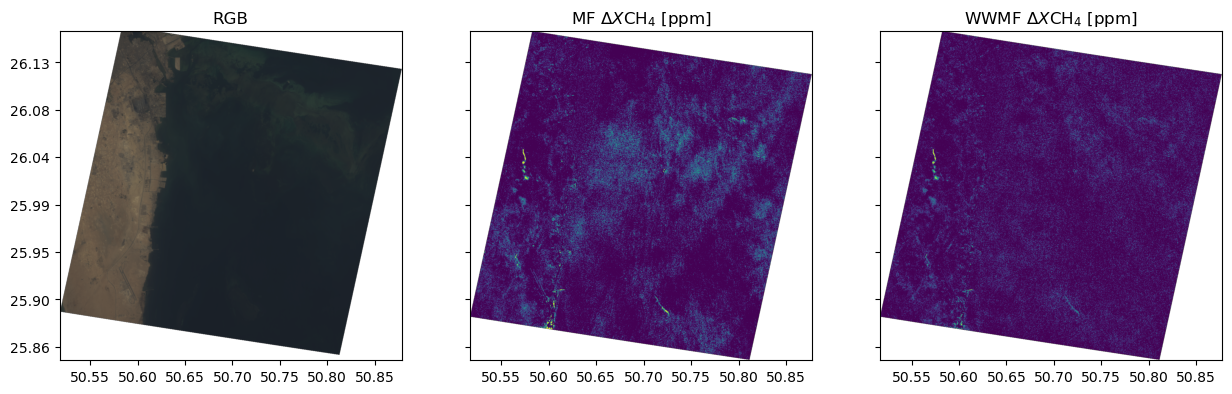

In [11]:
from georeader import plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1,3, figsize=(15,5), sharey=True)
plot.show(rgb, ax=ax[0], mask=True, title="RGB")

mf = cube_crs.isel({"band": 1})
plot.show(mf, ax=ax[1], vmin=0, vmax=.3, title= "MF $\Delta X$CH$_4$ [ppm]", mask=True)
wmf = cube_crs.isel({"band": 2})
plot.show(wmf, ax=ax[2], vmin=0, vmax=.3, title= "WWMF $\Delta X$CH$_4$ [ppm]", mask=True)

## Plume vetting

Plume vetting is a spectral validation step that checks whether the pixels inside each detected plume actually show the CH₄ absorption signature relative to nearby background pixels.

The method is described in:

> C. Xiang, D. R. Thompson, R. O. Green, J. E. Fahlen, A. K. Thorpe, P. G. Brodrick,
> R. W. Coleman, A. M. Lopez, and C. D. Elder, *Identification of false methane plumes
> for orbital imaging spectrometers: A case study with EMIT*,
> Remote Sensing of Environment, 2025.
> <https://www.sciencedirect.com/science/article/pii/S0034425725002640>

In [12]:
import geopandas as gpd
import pandas as pd
import numpy as np
from georeader.geotensor import GeoTensor
from marshsi.quantification import ATMOSPHERE_HEIGHT_METHANE
from marshsi import plume_vetting

from importlib import reload
reload(plume_vetting)

PLUMES_FILE = "../tests/data/plume_vetting/plumes_enmap.gpkg"
plumes_gdf = gpd.read_file(PLUMES_FILE)
polygons = [geom.geoms[0] for geom in plumes_gdf.geometry]

# Convert WMF from ppm → ppm·m (multiply by effective column height in metres)
wmf_values = wmf.values
if wmf_values.ndim == 3:
    wmf_values = wmf_values[0]
wmf_arr = np.where(
    wmf_values == wmf.fill_value_default,
    0,
    wmf_values * ATMOSPHERE_HEIGHT_METHANE,
)
wmf_arr = np.where(~np.isfinite(wmf_arr), 0, wmf_arr)

wmf_ppmxm = GeoTensor(wmf_arr, transform=wmf.transform, crs=wmf.crs,
                      fill_value_default=0)

results = plume_vetting.compute_enmap(
    enmapi=rst,
    cmf=wmf_ppmxm,
    polygons=polygons,
    min_polygon_size=20,
    random_seed=42,
)

summary = (
    pd.DataFrame.from_dict(results, orient="index")
    .reindex(columns=["D_norm", "alpha_con_len"])
    .rename_axis("polygon")
    .sort_index()
)
summary

,D_norm,alpha_con_len
polygon,,
0,1.000000,0.000395
1,0.720407,853.690012
2,1.000006,0.000209
3,0.190530,1581.460359
4,1.025111,135.211641
5,0.319122,1383.082694
6,0.240601,1069.328060
7,0.980710,86.338470
8,0.108064,4046.946673


Polygon 8: D_norm=0.108


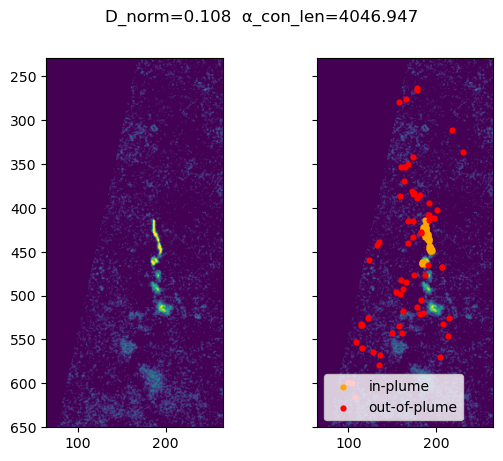

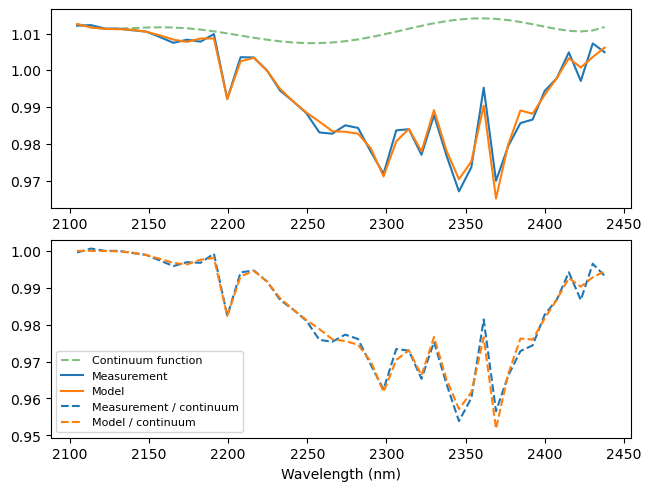

In [13]:
if results:
    best_idx = min(results, key=lambda k: results[k]["D_norm"])
    print(f"Polygon {best_idx}: D_norm={results[best_idx]['D_norm']:.3f}")
    plume_vetting.plot_vetting(results[best_idx], cmf_values=wmf_ppmxm.values)

The marshsi package and tutorials are released under a [Creative Commons non-commercial Share-Alike licence](https://creativecommons.org/licenses/by-nc-sa/4.0/legalcode.txt). For using the codes in comercial pipelines written consent by the authors must be provided.

 If you find this work useful please cite:

```
@Article{roger_2024,
    AUTHOR = {Roger, J. and Guanter, L. and Gorroño, J. and Irakulis-Loitxate, I.},
    TITLE = {Exploiting the entire near-infrared spectral range to improve the detection of methane plumes with high-resolution imaging spectrometers},
    JOURNAL = {Atmospheric Measurement Techniques},
    VOLUME = {17},
    YEAR = {2024},
    NUMBER = {4},
    PAGES = {1333--1346},
    URL = {https://amt.copernicus.org/articles/17/1333/2024/},
    DOI = {10.5194/amt-17-1333-2024}
}
```